In [34]:
%load_ext autoreload
%autoreload 2
import jax
import pgx
from pgx.experimental import auto_reset, act_randomly
from twentyfortyeight import *
import jax.numpy as jnp
from matplotlib import pyplot as plt

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [35]:
env = pgx.make("2048")
batch_size = 4096

init = jax.jit(jax.vmap(env.init))  # vectorize and JIT-compile
step = jax.jit(jax.vmap(auto_reset(env.step, env.init)))

key = jax.random.key(42)
key, subkey = jax.random.split(key)
keys = jax.random.split(subkey, batch_size)

In [36]:
state = init(keys)  # vectorized states
key, subkey = jax.random.split(key)
# policy_network = MLP(496, 4, subkey)
key, subkey = jax.random.split(key)
# value_network = MLP(496, 1, subkey)
obs_wrapper = ToInt(FlattenObservation())
ppo_network = model = PPONetwork(496, 4, key, obs_wrapper=obs_wrapper)
key, subkey = jax.random.split(key)
optim = optax.adamw(1e-4)
grad_step = eqx.filter_jit(make_grad_step(ppo_network, ppo_loss, optim, subkey, 16))
# opt_state = optim.init(eqx.filter(model, eqx.is_array))
timesteps = 8

In [37]:
losses = []
policy_losses = []
rewards = []
for i in range(1000):
    state, current_obs, traj = collect_trajectory(ppo_network, step, state, state.observation, key, timesteps)
    key, subkey = jax.random.split(key)
    (loss, metrics), ppo_network = grad_step(ppo_network, traj, state.observation, 0.99, 0.95, 0.2, 1, 0.01)
    losses.append(loss)
    policy_losses.append(metrics['policy_loss'])
    rewards.append(jnp.mean(traj.rewards))

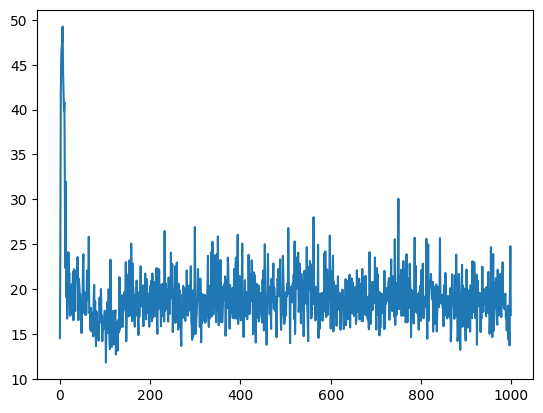

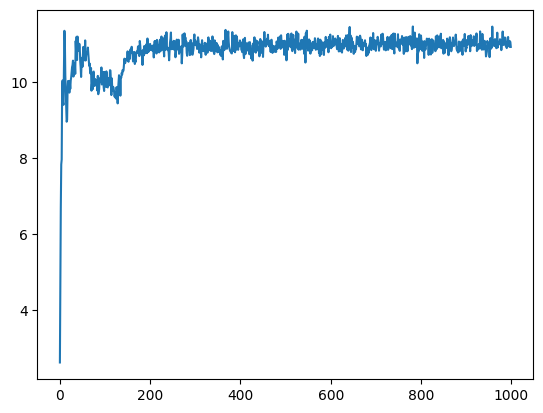

{'entropy_loss': Array(-0.007586, dtype=float32), 'policy_loss': Array(4.954636e-07, dtype=float32), 'value_loss': Array(17.123375, dtype=float32)}


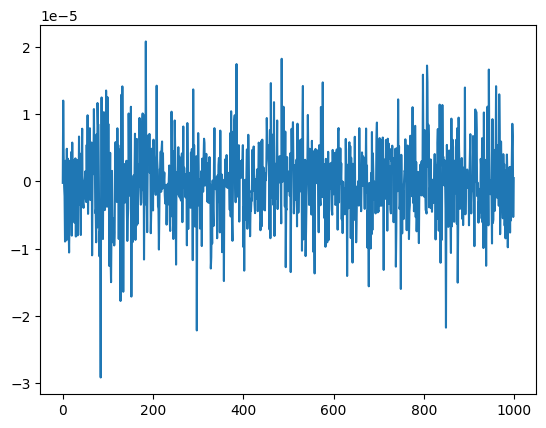

In [38]:
plt.plot(losses)
plt.show()
plt.plot(rewards)
plt.show()
plt.plot(policy_losses)
print(metrics)

In [39]:
jnp.sum(traj.rewards) / jnp.sum(traj.dones)

Array(1682.1597, dtype=float32)